Mean Squared Error (MSE) for Linear Model 1: 495.8333333333333
Mean Absolute Error (MAE) for Linear Model 1: 21.666666666666668
Mean Squared Error (MSE) for Linear Model 2: 151.99333333333325
Mean Absolute Error (MAE) for Linear Model 2: 6.233333333333339


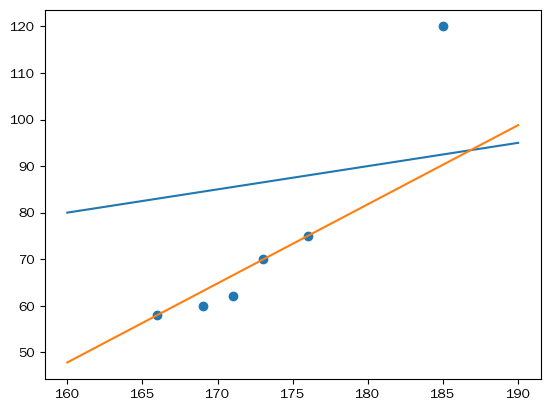

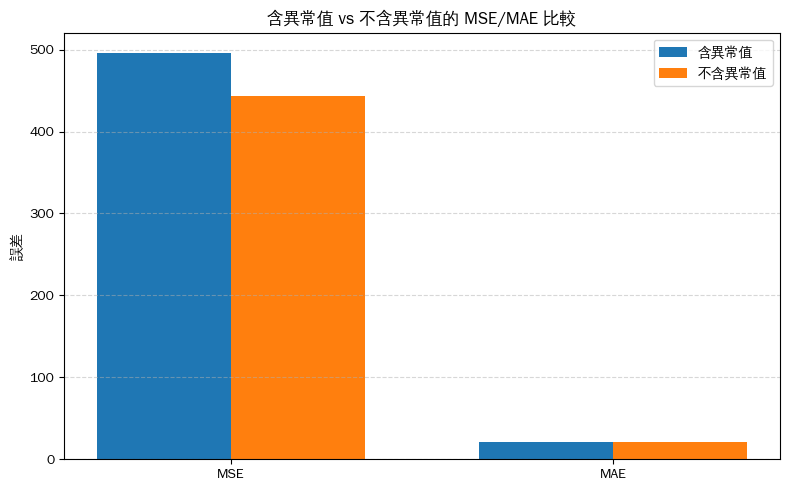

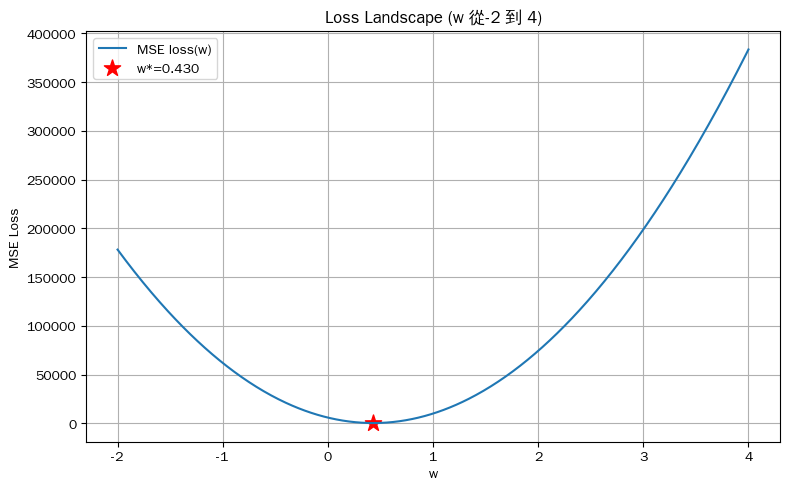

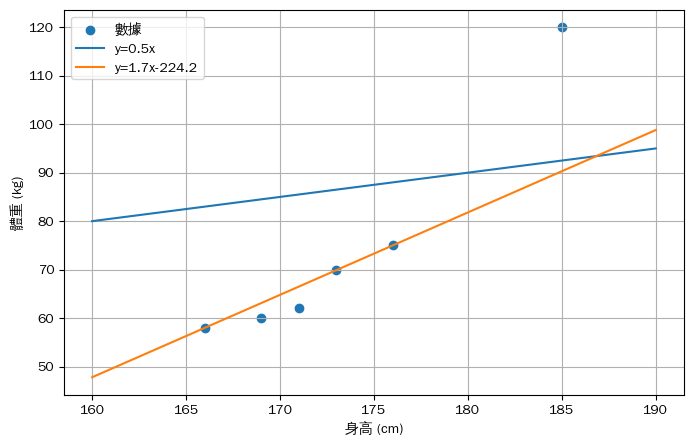

In [10]:
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# The problematic line `fm._rebuild()` has been removed.

plt.rcParams['font.family'] = 'sans-serif' # Ensure sans-serif is used for font family
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei'] # Set Chinese font
plt.rcParams['axes.unicode_minus'] = False  # Display negative sign correctly

x = np.array([166,176,171,173,169,185], dtype=float)
y_true = np.array([58,75,62,70,60,120], dtype=float)

plt.scatter(x, y_true, label="數據") # 畫散佈圖

x_line = np.linspace(160, 190, 100) # 畫線

linear1_line = 0.5 * x_line
plt.plot(x_line, linear1_line, label="y=0.5x")

linear2_line = 1.7 * x_line - 224.2
plt.plot(x_line, linear2_line, label="y=1.7x-224.2")


linear1 = 0.5 * x
linear2 = 1.7 * x - 224.2

y_pred1 = linear1
y_pred2 = linear2

y_pred3 = linear1
y_pred4 = linear2

mse1 = mean_squared_error(y_true, y_pred1)
mse2 = mean_squared_error(y_true, y_pred2)

mae1 = mean_absolute_error(y_true, y_pred3)
mae2 = mean_absolute_error(y_true, y_pred4)

print("Mean Squared Error (MSE) for Linear Model 1:", mse1)
print("Mean Absolute Error (MAE) for Linear Model 1:", mae1)
print("Mean Squared Error (MSE) for Linear Model 2:", mse2)
print("Mean Absolute Error (MAE) for Linear Model 2:", mae2)

# 第三題
outlier_index = np.where((x == 185) & (y_true == 120))[0]
if outlier_index.size > 0:
    x_no_outlier = np.delete(x, outlier_index)
    y_no_outlier = np.delete(y_true, outlier_index)
else:
    x_no_outlier = x.copy()
    y_no_outlier = y_true.copy()

# 以 y = 0.5x 作為基準模型
mse_full = mean_squared_error(y_true, 0.5 * x)
mae_full = mean_absolute_error(y_true, 0.5 * x)

mse_clean = mean_squared_error(y_no_outlier, 0.5 * x_no_outlier)
mae_clean = mean_absolute_error(y_no_outlier, 0.5 * x_no_outlier)

categories = ['MSE', 'MAE']
values_full = [mse_full, mae_full]
values_clean = [mse_clean, mae_clean]

plt.figure(figsize=(8, 5))
bar_width = 0.35
indices = np.arange(len(categories))
plt.bar(indices - bar_width/2, values_full, bar_width, label='含異常值')
plt.bar(indices + bar_width/2, values_clean, bar_width, label='不含異常值')
plt.xticks(indices, categories)
plt.ylabel('誤差')
plt.title('含異常值 vs 不含異常值的 MSE/MAE 比較')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()


# 第四題
w_values = np.linspace(-2, 4, 601)
loss_values = [mean_squared_error(y_true, w * x) for w in w_values]

w_star = w_values[np.argmin(loss_values)]
loss_star = min(loss_values)

plt.figure(figsize=(8,5))
plt.plot(w_values, loss_values, label='MSE loss(w)')
plt.scatter([w_star], [loss_star], color='red', marker='*', s=150, label=f'w*={w_star:.3f}')
plt.xlabel('w')
plt.ylabel('MSE Loss')
plt.title('Loss Landscape (w 從-2 到 4)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(x, y_true, label="數據")
plt.plot(x_line, linear1_line, label="y=0.5x")
plt.plot(x_line, linear2_line, label="y=1.7x-224.2")
plt.xlabel("身高 (cm)")
plt.ylabel("體重 (kg)")
plt.legend()
plt.grid()
plt.show()